# 03 — Antrenare si Evaluare Modele
## Detectia fraudelor financiare — RF, XGBoost, LightGBM

Acest notebook contine:
- Incarcarea datelor preprocesate (SMOTE)
- Antrenare RandomForest, XGBoost, LightGBM
- Evaluare pe test set: Precision, Recall, F1, AUC-PR, AUC-ROC
- Confusion matrices, curbe PR, comparatie metrici

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)

# Configurare
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
SEED = 42

FIGURES_DIR = os.path.join('..', 'figures')
MODELS_DIR = os.path.join('..', 'models')
DATA_DIR = os.path.join('..', 'data')
os.makedirs(MODELS_DIR, exist_ok=True)

print('Librarii incarcate cu succes.')

Librarii incarcate cu succes.


## 1. Incarcarea datelor preprocesate

In [2]:
# Incarcam datele salvate din 02_preprocessing
data = joblib.load(os.path.join(DATA_DIR, 'preprocessed.joblib'))

X_train_sm = data['X_train_sm']
y_train_sm = data['y_train_sm']
X_test = data['X_test']
y_test = data['y_test']
feature_names = data['feature_names']

print(f'Train SMOTE: {X_train_sm.shape[0]:,} tranzactii ({(y_train_sm == 1).sum():,} fraude, {(y_train_sm == 1).sum()/len(y_train_sm)*100:.2f}%)')
print(f'Test set:    {X_test.shape[0]:,} tranzactii ({(y_test == 1).sum():,} fraude, {(y_test == 1).sum()/len(y_test)*100:.3f}%)')
print(f'Features:    {len(feature_names)}')

Train SMOTE: 250,196 tranzactii (22,745 fraude, 9.09%)
Test set:    56,962 tranzactii (98 fraude, 0.172%)
Features:    30


## 2. Antrenare modele

In [3]:
# Definire modele
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        # scale_pos_weight RECALCULAT dupa SMOTE: n_neg/n_pos = 227451/22745 = 10.0
        # (anterior 577 = raportul pe distributia ORIGINALA -> efect de dubla
        #  ponderare cumulat cu SMOTE; corectat conform feedback)
        scale_pos_weight=10, random_state=SEED, n_jobs=-1,
        eval_metric='logloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        random_state=SEED, n_jobs=-1, verbose=-1
    ),
}

# Antrenare
trained_models = {}
for name, model in models.items():
    print(f'Antrenare {name}...', end=' ')
    start = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f'OK ({elapsed:.1f}s)')

print('\nToate modelele antrenate cu succes.')

Antrenare RandomForest... 

OK (55.9s)
Antrenare XGBoost... 

OK (2.4s)
Antrenare LightGBM... 

OK (2.4s)

Toate modelele antrenate cu succes.


## 3. Evaluare pe test set

In [4]:
# Predictii si probabilitati pe test set
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-PR': auc_pr,
        'AUC-ROC': auc_roc,
        'CM': cm,
    }
    
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['Legitima', 'Frauda']))


--- RandomForest ---
              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     56864
      Frauda       0.86      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962


--- XGBoost ---
              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     56864
      Frauda       0.76      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- LightGBM ---
              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     56864
      Frauda       0.73      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [5]:
# Tabel comparativ metrici
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['y_pred', 'y_proba', 'CM']}
    for name, res in results.items()
}).T

print('Tabel comparativ metrici (evaluat pe test set neatins):')
print(metrics_df.to_string(float_format='{:.4f}'.format))

Tabel comparativ metrici (evaluat pe test set neatins):
              Precision  Recall  F1-Score  AUC-PR  AUC-ROC
RandomForest     0.8646  0.8469    0.8557  0.8842   0.9738
XGBoost          0.7568  0.8571    0.8038  0.8720   0.9733
LightGBM         0.7304  0.8571    0.7887  0.8645   0.9771


## 4. Salvare modele

In [6]:
# Salvare modele cu joblib
model_files = {
    'RandomForest': 'rf_smote.joblib',
    'XGBoost': 'xgb_smote.joblib',
    'LightGBM': 'lgbm_smote.joblib',
}

for name, filename in model_files.items():
    path = os.path.join(MODELS_DIR, filename)
    joblib.dump(trained_models[name], path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f'Salvat: models/{filename} ({size_mb:.1f} MB)')

Salvat: models/rf_smote.joblib (13.5 MB)
Salvat: models/xgb_smote.joblib (0.3 MB)
Salvat: models/lgbm_smote.joblib (0.3 MB)


## 5. Figura 5.1 — Confusion Matrices

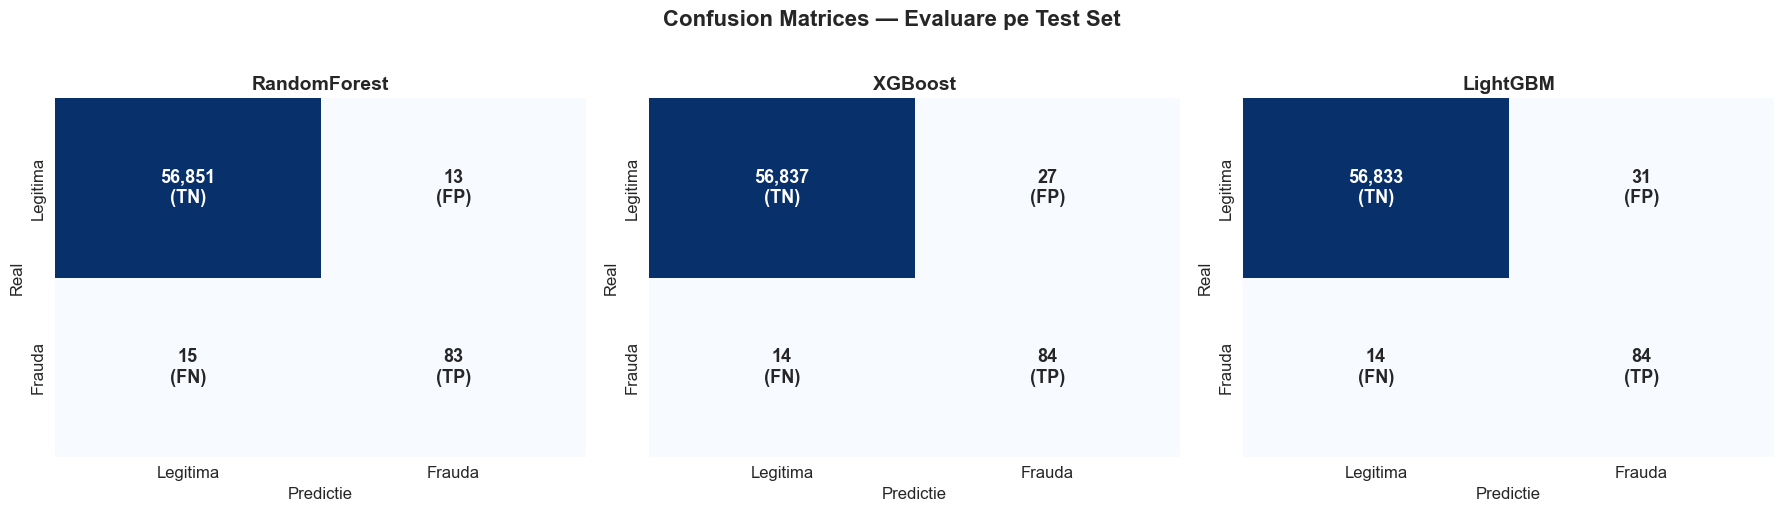

Salvat: figures/Figura_5_1.png


In [7]:
# Figura 5.1 — Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = res['CM']
    # Annotations cu valori absolute si procente
    labels = np.array([
        [f'{cm[0,0]:,}\n(TN)', f'{cm[0,1]:,}\n(FP)'],
        [f'{cm[1,0]:,}\n(FN)', f'{cm[1,1]:,}\n(TP)']
    ])
    sns.heatmap(
        cm, annot=labels, fmt='', cmap='Blues',
        xticklabels=['Legitima', 'Frauda'],
        yticklabels=['Legitima', 'Frauda'],
        ax=ax, cbar=False,
        annot_kws={'fontsize': 13, 'fontweight': 'bold'}
    )
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predictie')
    ax.set_ylabel('Real')

plt.suptitle('Confusion Matrices — Evaluare pe Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_5_1.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_5_1.png')

## 6. Figura 6.1 — Curbe Precision-Recall

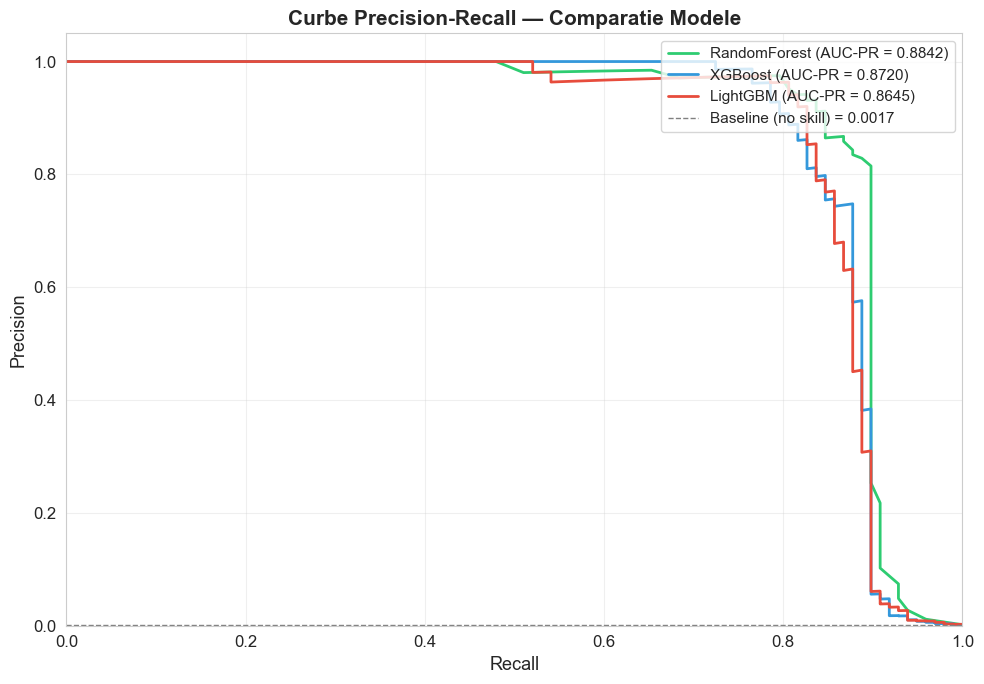

Salvat: figures/Figura_6_1.png


In [8]:
# Figura 6.1 — Curbe Precision-Recall comparative
fig, ax = plt.subplots(figsize=(10, 7))

colors_pr = ['#2ecc71', '#3498db', '#e74c3c']

for (name, res), color in zip(results.items(), colors_pr):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(recall_vals, precision_vals, color=color, linewidth=2,
            label=f'{name} (AUC-PR = {res["AUC-PR"]:.4f})')

# Linia baseline (proportia fraudelor in test set)
baseline = (y_test == 1).sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline (no skill) = {baseline:.4f}')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Curbe Precision-Recall — Comparatie Modele', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_6_1.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_6_1.png')

## 7. Figura 6.2 — Bar Chart Comparativ Metrici

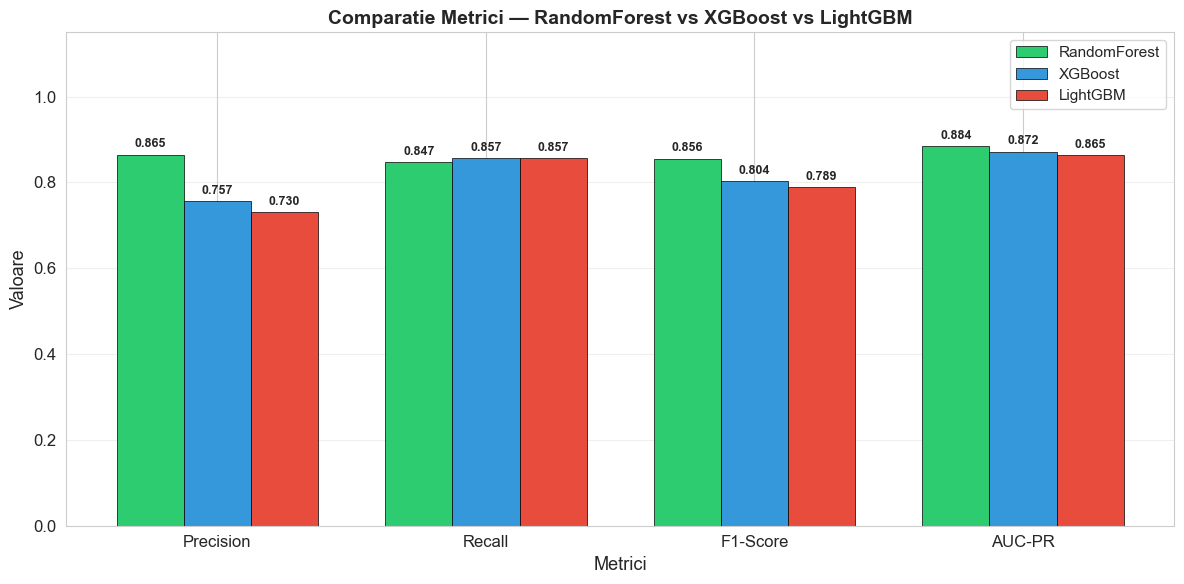

Salvat: figures/Figura_6_2.png


In [9]:
# Figura 6.2 — Bar chart comparativ metrici
fig, ax = plt.subplots(figsize=(12, 6))

metric_names = ['Precision', 'Recall', 'F1-Score', 'AUC-PR']
model_names = list(results.keys())
colors_bar = ['#2ecc71', '#3498db', '#e74c3c']

x = np.arange(len(metric_names))
width = 0.25

for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    values = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=name, color=color,
                  edgecolor='black', linewidth=0.5)
    # Valori pe bare
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrici', fontsize=13)
ax.set_ylabel('Valoare', fontsize=13)
ax.set_title('Comparatie Metrici — RandomForest vs XGBoost vs LightGBM', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_6_2.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_6_2.png')

## SUMMARY

In [10]:
# Statistici cheie — celula SUMMARY
print('=' * 75)
print('SUMMARY — 03 Models (RF, XGBoost, LightGBM pe SMOTE)')
print('=' * 75)
print(f'Train set:  SMOTE ({X_train_sm.shape[0]:,} tranzactii, {(y_train_sm==1).sum():,} fraude)')
print(f'Test set:   Original ({X_test.shape[0]:,} tranzactii, {(y_test==1).sum()} fraude, distributie reala)')
print('-' * 75)
print(f'{"Model":<15} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"AUC-PR":>10} {"AUC-ROC":>10}')
print('-' * 75)
for name, res in results.items():
    print(f'{name:<15} {res["Precision"]:>10.4f} {res["Recall"]:>10.4f} {res["F1-Score"]:>10.4f} {res["AUC-PR"]:>10.4f} {res["AUC-ROC"]:>10.4f}')
print('-' * 75)

# Cel mai bun model dupa AUC-PR
best_name = max(results, key=lambda k: results[k]['AUC-PR'])
print(f'\nCel mai bun model (AUC-PR): {best_name} ({results[best_name]["AUC-PR"]:.4f})')

print(f'\nConfusion Matrices:')
for name, res in results.items():
    cm = res['CM']
    print(f'  {name}: TN={cm[0,0]:,} FP={cm[0,1]:,} FN={cm[1,0]:,} TP={cm[1,1]:,}')

print(f'\nModele salvate:')
for name, filename in model_files.items():
    print(f'  models/{filename}')

print(f'\nFiguri generate:')
print(f'  Figura_5_1.png — Confusion matrices (3 modele)')
print(f'  Figura_6_1.png — Curbe Precision-Recall comparative')
print(f'  Figura_6_2.png — Bar chart comparativ metrici')
print('=' * 75)

SUMMARY — 03 Models (RF, XGBoost, LightGBM pe SMOTE)
Train set:  SMOTE (250,196 tranzactii, 22,745 fraude)
Test set:   Original (56,962 tranzactii, 98 fraude, distributie reala)
---------------------------------------------------------------------------
Model            Precision     Recall   F1-Score     AUC-PR    AUC-ROC
---------------------------------------------------------------------------
RandomForest        0.8646     0.8469     0.8557     0.8842     0.9738
XGBoost             0.7568     0.8571     0.8038     0.8720     0.9733
LightGBM            0.7304     0.8571     0.7887     0.8645     0.9771
---------------------------------------------------------------------------

Cel mai bun model (AUC-PR): RandomForest (0.8842)

Confusion Matrices:
  RandomForest: TN=56,851 FP=13 FN=15 TP=83
  XGBoost: TN=56,837 FP=27 FN=14 TP=84
  LightGBM: TN=56,833 FP=31 FN=14 TP=84

Modele salvate:
  models/rf_smote.joblib
  models/xgb_smote.joblib
  models/lgbm_smote.joblib

Figuri generate:
  